<div dir="rtl" style="text-align:right; line-height:1.9;">

# بخش دوم پروژه — خوشه‌بندی و رگرسیون

این نسخه، نوت‌بوک اصلی را به شکل تمیز و مرحله‌بندی‌شده بازسازی می‌کند.  
مسیر نهایی پروژه به‌صورت واضح شامل **ترکیب داده‌ها، Feature Engineering، Clustering، مقایسه مدل‌های Regression، Cross-Validation و انتخاب مدل نهایی** است.

### مدل نهایی انتخاب‌شده
**HistGradientBoostingRegressor**

نتیجه نهایی ثبت‌شده:
- CV R² Mean = **0.866408**
- Test MAE = **0.856924**
- Test RMSE = **1.467050**
- Test R² = **0.860794**

</div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import KMeans, AgglomerativeClustering, Birch
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

<div dir="rtl" style="text-align:right; line-height:1.9;">

## 1. بارگذاری، ترکیب و مهندسی ویژگی‌ها

دو فایل ریاضی و پرتغالی به‌صورت عمودی با `concat` ترکیب می‌شوند.  
هر ردیف یک دانش‌آموز در یک درس است و ستون `course` نوع درس را مشخص می‌کند.

</div>

In [2]:
mat = pd.read_csv("student-mat.csv", sep=";")
por = pd.read_csv("student-por.csv", sep=";")

mat["course"] = "math"
por["course"] = "portuguese"

df = pd.concat([mat, por], ignore_index=True)

df["grade_improvement"] = df["G2"] - df["G1"]
df["grade_mean_12"] = (df["G1"] + df["G2"]) / 2
df["grade_min_12"] = df[["G1", "G2"]].min(axis=1)
df["grade_max_12"] = df[["G1", "G2"]].max(axis=1)
df["grade_range_12"] = abs(df["G2"] - df["G1"])
df["study_fail_ratio"] = df["failures"] / (df["studytime"] + 1)
df["absence_per_study"] = df["absences"] / (df["studytime"] + 1)
df["parent_edu_mean"] = (df["Medu"] + df["Fedu"]) / 2
df["alcohol_total"] = df["Dalc"] + df["Walc"]
df["social_activity"] = df["goout"] + df["freetime"]
df["early_risk"] = ((df["G1"] < 10) | (df["G2"] < 10)).astype(int)

print("Math:", mat.shape)
print("Portuguese:", por.shape)
print("Combined:", df.shape)

display(df[[
    "course", "G1", "G2", "G3",
    "grade_improvement", "grade_mean_12", "grade_range_12",
    "study_fail_ratio", "absence_per_study", "early_risk"
]].head())

Math: (395, 34)
Portuguese: (649, 34)
Combined: (1044, 45)


,course,G1,G2,G3,grade_improvement,grade_mean_12,grade_range_12,study_fail_ratio,absence_per_study,early_risk
0,math,5,6,6,1,5.5,1,0.0,2.000000,1
1,math,5,5,6,0,5.0,0,0.0,1.333333,1
2,math,7,8,10,1,7.5,1,1.0,3.333333,1
3,math,15,14,15,-1,14.5,1,0.0,0.500000,0
4,math,6,10,10,4,8.0,4,0.0,1.333333,1


<div dir="rtl" style="text-align:right; line-height:1.9;">

## 2. خوشه‌بندی

برای خوشه‌بندی، `G3` از ورودی حذف می‌شود. متغیرهای عددی استاندارد و متغیرهای دسته‌ای One-Hot Encode می‌شوند.  
ابتدا مقدارهای مختلف `k` بررسی می‌شوند، سپس مطابق صورت پروژه تحلیل اصلی با `k=3` انجام می‌شود.

</div>

In [3]:
cluster_df = df.drop(columns=["G3"])

cat_cols = cluster_df.select_dtypes(include=["object", "string"]).columns
num_cols = cluster_df.columns.difference(cat_cols)

cluster_preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
])

X_cluster = cluster_preprocessor.fit_transform(cluster_df)

k_results = []

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X_cluster)
    k_results.append([
        k,
        silhouette_score(X_cluster, labels),
        davies_bouldin_score(X_cluster, labels),
        km.inertia_
    ])

k_results = pd.DataFrame(
    k_results,
    columns=["k", "Silhouette", "Davies_Bouldin", "Inertia"]
)

display(k_results.round(6))

print("Best k by Silhouette:",
      int(k_results.loc[k_results["Silhouette"].idxmax(), "k"]))
print("Best k by Davies-Bouldin:",
      int(k_results.loc[k_results["Davies_Bouldin"].idxmin(), "k"]))

,k,Silhouette,Davies_Bouldin,Inertia
0,2,0.144434,2.421274,30251.249776
1,3,0.118237,2.503215,28572.743173
2,4,0.087269,2.523908,27188.229362
3,5,0.075476,2.617308,25958.784748
4,6,0.083047,2.398619,24973.615663
5,7,0.079864,2.411912,24404.033262
6,8,0.071751,2.344377,23598.948505


Best k by Silhouette: 2
Best k by Davies-Bouldin: 8


In [4]:
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=20)
df["KMeans_3"] = kmeans.fit_predict(X_cluster)

profile = df.groupby("KMeans_3")[[
    "G1", "G2", "G3", "studytime", "failures", "absences",
    "grade_improvement", "study_fail_ratio", "early_risk"
]].mean().round(2)

profile["Count"] = df["KMeans_3"].value_counts().sort_index()

print("K-Means k=3")
print("Silhouette:", round(silhouette_score(X_cluster, df["KMeans_3"]), 6))
print("Davies-Bouldin:", round(davies_bouldin_score(X_cluster, df["KMeans_3"]), 6))

display(pd.crosstab(df["course"], df["KMeans_3"]))
display(profile)

K-Means k=3
Silhouette: 0.118237
Davies-Bouldin: 2.503215


KMeans_3,0,1,2
course,,,
math,73,180,142
portuguese,125,354,170


,G1,G2,G3,studytime,failures,absences,grade_improvement,study_fail_ratio,early_risk,Count
KMeans_3,,,,,,,,,,
0,10.77,10.90,11.07,1.72,0.20,6.91,0.13,0.08,0.32,198
1,13.21,13.33,13.66,2.17,0.05,3.34,0.12,0.02,0.01,534
2,8.08,7.91,7.56,1.78,0.68,4.74,-0.17,0.28,0.95,312


Hierarchical,0,1,2
course,,,
math,199,62,134
portuguese,271,100,278


,Method,Silhouette,Davies_Bouldin
0,K-Means,0.118237,2.503215
2,Gaussian Mixture,0.106043,3.498571
1,Hierarchical,0.055894,3.331607
3,BIRCH,0.055894,3.331607


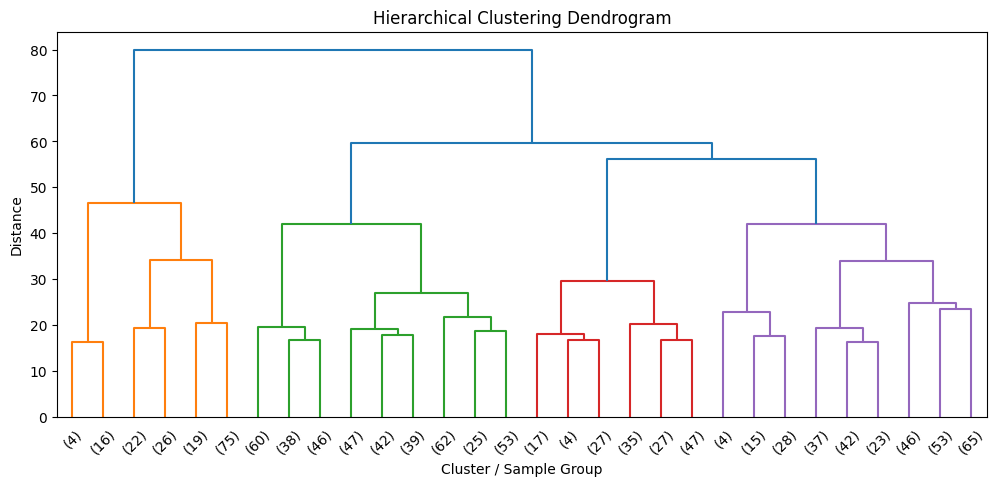

Best clustering method by Silhouette: K-Means


In [5]:
hierarchical = AgglomerativeClustering(n_clusters=3, linkage="ward")
df["Hierarchical"] = hierarchical.fit_predict(X_cluster)

gmm = GaussianMixture(n_components=3, random_state=RANDOM_STATE)
gmm_labels = gmm.fit_predict(X_cluster)

birch = Birch(n_clusters=3)
birch_labels = birch.fit_predict(X_cluster)

clustering_results = pd.DataFrame({
    "Method": ["K-Means", "Hierarchical", "Gaussian Mixture", "BIRCH"],
    "Silhouette": [
        silhouette_score(X_cluster, df["KMeans_3"]),
        silhouette_score(X_cluster, df["Hierarchical"]),
        silhouette_score(X_cluster, gmm_labels),
        silhouette_score(X_cluster, birch_labels)
    ],
    "Davies_Bouldin": [
        davies_bouldin_score(X_cluster, df["KMeans_3"]),
        davies_bouldin_score(X_cluster, df["Hierarchical"]),
        davies_bouldin_score(X_cluster, gmm_labels),
        davies_bouldin_score(X_cluster, birch_labels)
    ]
}).sort_values("Silhouette", ascending=False)

display(pd.crosstab(df["course"], df["Hierarchical"]))
display(clustering_results.round(6))

Z = linkage(X_cluster, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode="lastp", p=30, show_leaf_counts=True, leaf_rotation=45)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster / Sample Group")
plt.ylabel("Distance")
plt.show()

print("Best clustering method by Silhouette:",
      clustering_results.iloc[0]["Method"])


##  رگرسیون و پیش‌بینی 


In [6]:
X = df.drop(columns=["G3", "KMeans_3", "Hierarchical"])
y = df["G3"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

cat_cols_r = X_train.select_dtypes(include=["object", "string"]).columns
num_cols_r = X_train.columns.difference(cat_cols_r)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols_r),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols_r)
])

X_train_t = preprocessor.fit_transform(X_train)
X_test_t = preprocessor.transform(X_test)

models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=600,
        max_depth=8,
        max_features=0.7,
        min_samples_split=6,
        min_samples_leaf=3,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.02,
        max_depth=2,
        min_child_weight=1,
        subsample=0.8,
        colsample_bytree=0.7,
        reg_lambda=1,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=500,
        max_features=0.9,
        min_samples_leaf=1,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        learning_rate=0.03,
        max_iter=200,
        max_leaf_nodes=7,
        min_samples_leaf=15,
        l2_regularization=0,
        random_state=RANDOM_STATE
    )
}

regression_rows = []
regression_predictions = {}

for name, model in models.items():
    model.fit(X_train_t, y_train)
    pred = np.clip(model.predict(X_test_t), 0, 20)
    regression_predictions[name] = pred

    regression_rows.append([
        name,
        mean_absolute_error(y_test, pred),
        np.sqrt(mean_squared_error(y_test, pred)),
        r2_score(y_test, pred)
    ])

regression_results = pd.DataFrame(
    regression_rows,
    columns=["Model", "MAE", "RMSE", "R2"]
).sort_values("R2", ascending=False)

display(regression_results.round(6))

print("Best model on independent Test:", regression_results.iloc[0]["Model"])
print("Best Test R2:", round(regression_results.iloc[0]["R2"], 6))

,Model,MAE,RMSE,R2
3,HistGradientBoosting,0.856924,1.467050,0.860794
1,XGBoost,0.873119,1.548064,0.844995
0,Random Forest,0.874176,1.566337,0.841314
2,Extra Trees,1.004775,1.751620,0.801552


Best model on independent Test: HistGradientBoosting
Best Test R2: 0.860794



##  ارزیابی نهایی مدل منتخب


,Metric,Value
0,CV R2 Mean,0.866408
1,CV R2 Std,0.032069
2,Test MAE,0.856924
3,Test RMSE,1.467050
4,Test R2,0.860794


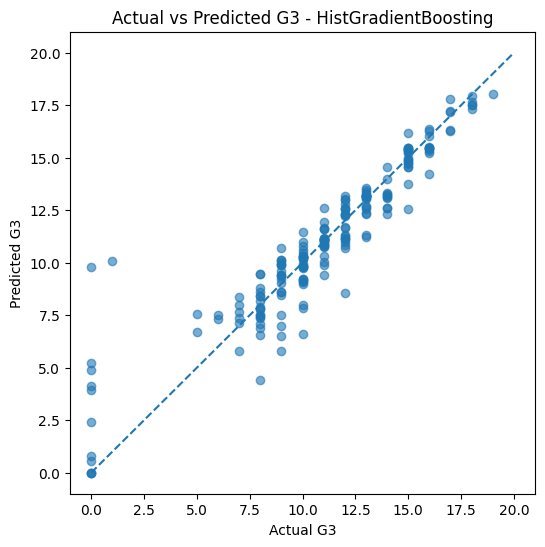

In [7]:
final_preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols_r),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols_r)
])

final_model = Pipeline([
    ("prep", final_preprocessor),
    ("model", HistGradientBoostingRegressor(
        learning_rate=0.03,
        max_iter=200,
        max_leaf_nodes=7,
        min_samples_leaf=15,
        l2_regularization=0,
        random_state=RANDOM_STATE
    ))
])

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_r2 = cross_val_score(
    final_model,
    X_train,
    y_train,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

final_model.fit(X_train, y_train)
final_pred = np.clip(final_model.predict(X_test), 0, 20)

final_results = pd.DataFrame({
    "Metric": ["CV R2 Mean", "CV R2 Std", "Test MAE", "Test RMSE", "Test R2"],
    "Value": [
        cv_r2.mean(),
        cv_r2.std(),
        mean_absolute_error(y_test, final_pred),
        np.sqrt(mean_squared_error(y_test, final_pred)),
        r2_score(y_test, final_pred)
    ]
})

display(final_results.round(6))

plt.figure(figsize=(6, 6))
plt.scatter(y_test, final_pred, alpha=0.6)
plt.plot([0, 20], [0, 20], "--")
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vs Predicted G3 - HistGradientBoosting")
plt.show()